First, import everything.

In [8]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

Scrape Wikipedia for S&P500 constituents.

In [9]:
# Option: load from Wikipedia for freshest data
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
df = pd.read_html(url)[0]
tickers = [t.strip() for t in df['Symbol'].tolist()]

# Example usage
print(f"There are {len(tickers)} tickers in the S&P 500:")
print(tickers[:20], "...")  # show first 20 tickers

There are 503 tickers in the S&P 500:
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A', 'APD', 'ABNB', 'AKAM', 'ALB', 'ARE', 'ALGN', 'ALLE', 'LNT', 'ALL', 'GOOGL'] ...


Find all mean daily returns over the last ~2.5 years

In [58]:
def summary_stats(ticker):
    df = yf.download(ticker, start="2023-01-01", auto_adjust=True, progress=False)
    if df.empty:
        return None  # skip if no data
    
    df["DailyReturn"] = (df["Close"] - df["Open"]) / df["Open"]
    returns = df["DailyReturn"].dropna()
    
    if returns.empty:
        return None
    
    summary_stats = {
        "Ticker": ticker,
        "Mean": returns.mean(),
        "Median": returns.median(),
        "Std Dev": returns.std(),
        "Min": returns.min(),
        "Max": returns.max(),
        "Count": returns.count()
    }
    return summary_stats

# Example: tickers list from earlier
# tickers = ["AAPL", "MSFT", "GOOGL"]

all_stats = []
for ticker in tickers:
    stats = summary_stats(ticker)
    if stats:  # skip if None
        all_stats.append(stats)
        print(f"{ticker} complete")
    else:
        print(f"{ticker} empty")

# Create a DataFrame of all results
summary_df = pd.DataFrame(all_stats)

# Save to CSV locally
summary_df.to_csv("sp500_summary_stats.csv", index=False)

print(f"Saved summary stats for {len(summary_df)} tickers to sp500_summary_stats.csv")

MMM complete
AOS complete
ABT complete
ABBV complete
ACN complete
ADBE complete
AMD complete
AES complete
AFL complete
A complete
APD complete
ABNB complete
AKAM complete
ALB complete


KeyboardInterrupt: 

           Mean   Median   Std Dev       Min       Max  Count  Total Return
Value  0.001421  0.00085  0.014071 -0.076486  0.156441    662           NaN


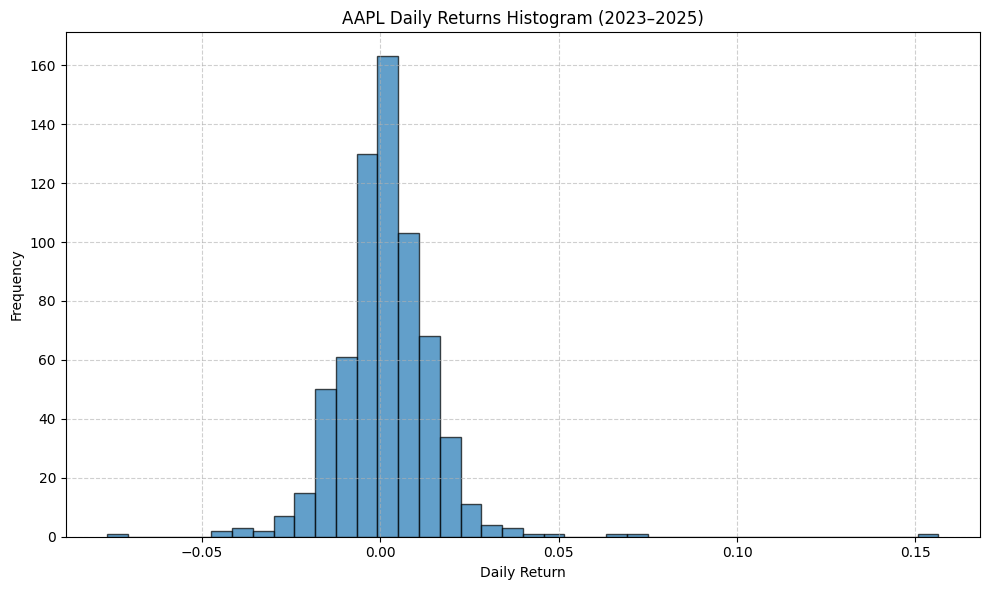

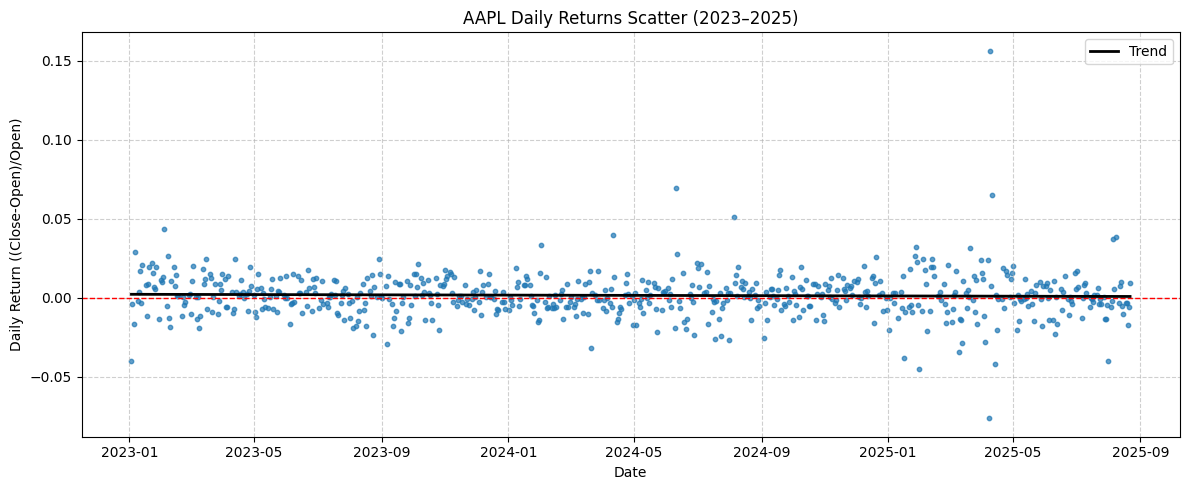

In [10]:
# --- Pick your ticker here ---
ticker = "AAPL"

# 1) Download data from 2023-01-01 to today
df = yf.download(ticker, start="2023-01-01", auto_adjust=True, progress=False)

# 2) Calculate daily return (Close - Open) / Open
df["DailyReturn"] = (df["Close"] - df["Open"]) / df["Open"]

# 3) Calculate total return over the period (robust to missing values)
close_non_na = df["Close"].dropna()
total_return = np.nan
if len(close_non_na) >= 2:
    total_return = (close_non_na.iloc[-1] / close_non_na.iloc[0]) - 1

# 4) Filter out NaNs
returns = df["DailyReturn"].dropna()

# 5) Summary statistics
summary_stats = {
    "Mean": returns.mean(),
    "Median": returns.median(),
    "Std Dev": returns.std(),
    "Min": returns.min(),
    "Max": returns.max(),
    "Count": returns.count(),
    "Total Return": total_return
}
summary_df = pd.DataFrame(summary_stats, index=["Value"])
print(summary_df)

# 6) Existing histogram (kept as-is, but titled with the ticker)
plt.figure(figsize=(10, 6))
plt.hist(returns, bins=40, edgecolor='black', alpha=0.7)
plt.title(f"{ticker} Daily Returns Histogram (2023–2025)")
plt.xlabel("Daily Return")
plt.ylabel("Frequency")
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

# 7) NEW scatter plot: date on x-axis, return on y-axis, with horizontal 0 line + trend line
plt.figure(figsize=(12, 5))
plt.scatter(returns.index, returns.values, s=10, alpha=0.7)
plt.axhline(0, color='red', linestyle='--', linewidth=1)  # zero line

# Fit a simple linear trend (convert dates to numbers for regression)
x_numeric = returns.index.map(pd.Timestamp.toordinal).values
y = returns.values
m, b = np.polyfit(x_numeric, y, 1)
plt.plot(returns.index, m * x_numeric + b, color='black', linewidth=2, label='Trend')

plt.title(f"{ticker} Daily Returns Scatter (2023–2025)")
plt.xlabel("Date")
plt.ylabel("Daily Return ((Close-Open)/Open)")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plt.show()

In [ ]:
print(df["Close"].iloc[-1])
print(df["Close"].iloc[0])

(522.47998 - 234.80896)/234.80896

Ticker
ALB    81.43
Name: 2025-08-14 00:00:00, dtype: float64
Ticker
ALB    206.878616
Name: 2023-01-03 00:00:00, dtype: float64


1.2251279508243635

: 